# Flower Classification

### *Part II - Computer Vision Task: Image Classification with CNN*
<br>

**Module:** 6CS012 Artificial Intelligence
<br>
**Task:** Image Classification using Convolutional Neural Networks

**Project Type:** Collaborative Portfolio Project

**Students:**

* Aditi Paudel: *2408635*
* Bandana Yadav: *2408186*
* Isha Bhatta: *2408180*
* Pratisha Bista: *2408284*

**Group:** L6CG1

# Part A: Designing and Analyzing Convolutional Neural Networks from Scratch

### Dataset Description

The dataset used in this project is a **flower image classification dataset** consisting of photographs of five different flower species:

* Daisy
* Dandelion
* Rose
* Sunflower
* Tulip

Hence a **multi-class classification problem**.

The dataset is organised into class-specific directories, where each folder contains images corresponding to one flower category.

### Nature of the Learning Task

* **Task Type:** Supervised Learning
* **Problem Category:** Multi-class Image Classification
* **Input:** RGB flower images
* **Output:** Predicted flower category label

## 1. Data Understanding, Analysis, Visualization and Cleaning

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import math
import time
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# define paths to the dataset directories
DATASET_PATH = Path('/content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Flower Classification')
MODELS_PATH = DATASET_PATH.parent / "6CS012_CNN_Models"
FIGURES_PATH = DATASET_PATH.parent / "Figures"

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

train_path = DATASET_PATH / "Train"
test_path  = DATASET_PATH / "Test"

try:
    print("Dataset root contents:", os.listdir(DATASET_PATH))
    print("Train folder contents:", os.listdir(train_path))
    print("Test folder contents:",  os.listdir(test_path))
except FileNotFoundError as e:
    print(f"Error: One or more dataset directories not found: {e}")
except Exception as e:
    print(f"An unexpected error occurred while listing directory contents: {e}")

Dataset root contents: ['Train', 'Test']
Train folder contents: ['rose', 'sunflower', 'daisy', 'dandelion', 'tulip']
Test folder contents: ['38287568_627de6ca20.jpg', '110472418_87b6a3aa98_m.jpg', '15207766_fc2f1d692c_n.jpg', '27465811_9477c9d044.jpg', '8475769_3dea463364_m.jpg']


In [ ]:
def save_plot(fig, filename):
    """
    Saves a matplotlib figure to the FIGURES_PATH directory.
    Args:
        fig (matplotlib.figure.Figure): The figure object to save.
        filename (str): The name of the file to save the figure as.
    """
    full_path = os.path.join(FIGURES_PATH, filename)
    try:
        fig.savefig(full_path, bbox_inches='tight', dpi=150)
        print(f"Plot saved to: {full_path}")
    except Exception as e:
        print(f"Error saving plot to {full_path}: {e}")

### Dataset Statistics

In [ ]:
# get class names from subdirectories within the training path
class_names = sorted([
    folder.name for folder in train_path.iterdir()
    if folder.is_dir()
])

print("\nDetected Classes:")
for cls in class_names:
    print(f"  {cls}")

print("\nTotal Classes:", len(class_names))


Detected Classes:
  daisy
  dandelion
  rose
  sunflower
  tulip

Total Classes: 5


In [ ]:
# define valid image file extensions
valid_extensions = ('.jpg', '.jpeg', '.png')
train_counts = {}
test_counts  = {}

# count training images per class
for cls in class_names:
    class_dir = train_path / cls
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(valid_extensions)]
    train_counts[cls] = len(images)

# count test images per class (if available)
for cls in class_names:
    class_dir = test_path / cls
    if class_dir.exists():
        images = [f for f in os.listdir(class_dir) if f.lower().endswith(valid_extensions)]
        test_counts[cls] = len(images)
    else:
        test_counts[cls] = 0

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

print(f"{'Class':<12} {'Train':>8} {'Train%':>8} {'Test':>8}")
print("-" * 42)
for cls in class_names:
    count = train_counts[cls]
    pct   = (count / total_train) * 100
    print(f"{cls:<12} {count:>8d} {pct:>7.1f}% {test_counts[cls]:>8d}")
print("-" * 42)
print(f"{'TOTAL':<12} {total_train:>8d} {'100.0%':>8} {total_test:>8d}")

Class           Train   Train%     Test
------------------------------------------
daisy             756    17.7%        0
dandelion        1044    24.4%        0
rose              776    18.1%        0
sunflower         725    17.0%        0
tulip             976    22.8%        0
------------------------------------------
TOTAL            4277   100.0%        0


### Checking Class Imbalance

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/class_distribution_training_set.png


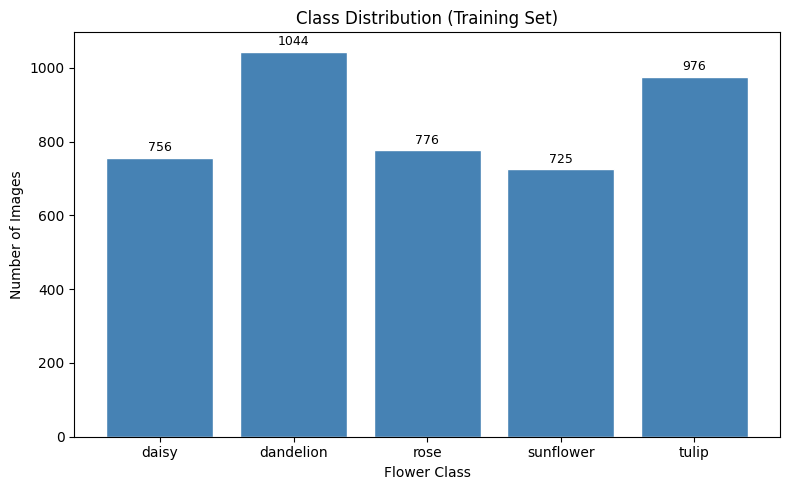

In [ ]:
# bar plot for class distribution in the training set
fig = plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, [train_counts[c] for c in class_names], color='steelblue', edgecolor='white')

# annotate bars with count
for bar, cls in zip(bars, class_names):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 10,
             str(train_counts[cls]),
             ha='center', va='bottom', fontsize=9)

plt.title("Class Distribution (Training Set)")
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.tight_layout()
save_plot(fig, "class_distribution_training_set.png")
plt.show()

In [ ]:
# check for class imbalance by calculating max/min ratio
max_count = max(train_counts.values())
min_count = min(train_counts.values())
ratio = max_count / min_count

print(f"Max class: {max(train_counts, key=train_counts.get)} ({max_count} images)")
print(f"Min class: {min(train_counts, key=train_counts.get)} ({min_count} images)")
print(f"\nImbalance Ratio (max/min): {ratio:.2f}")

if ratio < 1.5:
    print("Dataset is relatively balanced.")
else:
    print("Dataset is imbalanced — consider weighted loss or oversampling.")

Max class: dandelion (1044 images)
Min class: sunflower (725 images)

Imbalance Ratio (max/min): 1.44
Dataset is relatively balanced.


Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/sample_flower_images.png


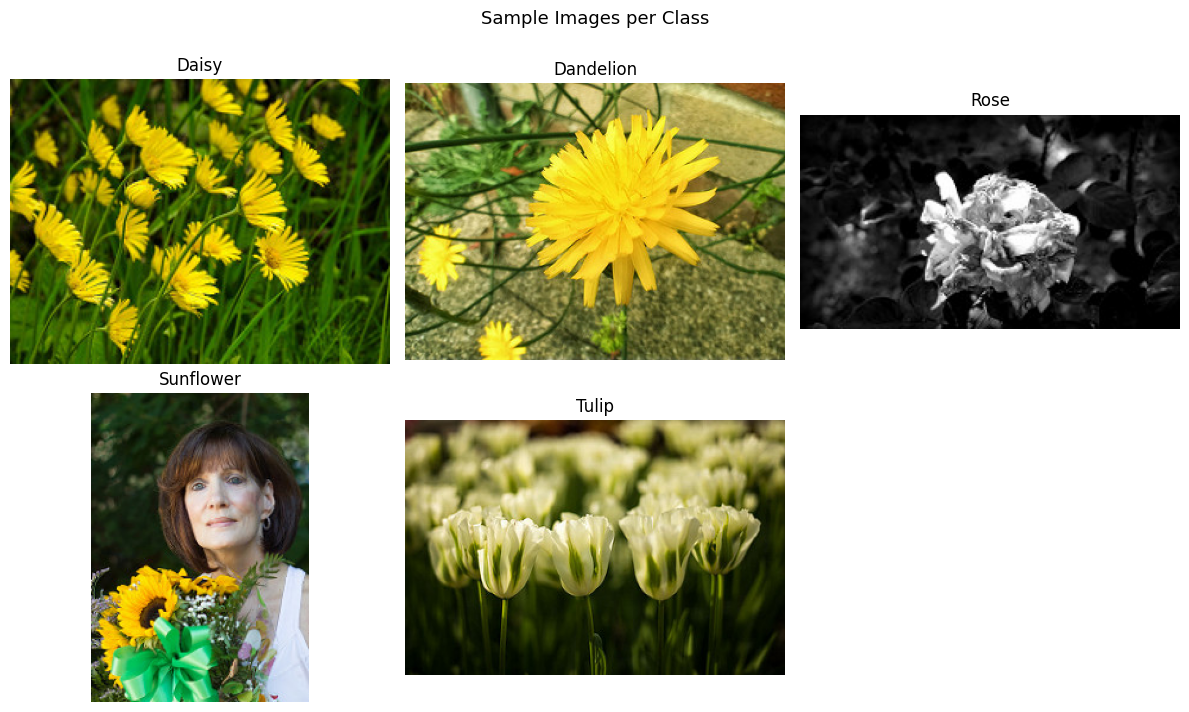

In [ ]:
cols = 3
rows = math.ceil(len(class_names) / cols)

fig = plt.figure(figsize=(12, 7))

for i, cls in enumerate(class_names):
    plt.subplot(rows, cols, i + 1)
    images = [f for f in os.listdir(train_path / cls) if f.lower().endswith(valid_extensions)]
    img_path = train_path / cls / random.choice(images)
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(cls.capitalize())
    plt.axis('off')

plt.suptitle("Sample Images per Class", fontsize=13, y=1.01)
plt.tight_layout()
save_plot(fig, "sample_flower_images.png")
plt.show()

### Image Dimension Analysis

In [ ]:
image_sizes = []

for cls in class_names:
    class_dir = train_path / cls
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(valid_extensions)]
    sample_images = images[:100]
    for img_name in sample_images:
        img = cv2.imread(str(class_dir / img_name))
        if img is not None:
            h, w = img.shape[:2]
            image_sizes.append((h, w))

print(f"Total images analysed: {len(image_sizes)}")

Total images analysed: 500


In [ ]:
heights = [s[0] for s in image_sizes]
widths  = [s[1] for s in image_sizes]

print("Height Statistics")
print(f"  Min: {min(heights)}  |  Max: {max(heights)}  |  Average: {int(np.mean(heights))}")

print("\nWidth Statistics")
print(f"  Min: {min(widths)}  |  Max: {max(widths)}  |  Average: {int(np.mean(widths))}")

print(f"\nUnique image sizes detected: {len(set(image_sizes))}")

Height Statistics
  Min: 119  |  Max: 414  |  Average: 255

Width Statistics
  Min: 156  |  Max: 500  |  Average: 345

Unique image sizes detected: 120


Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/image_dimension_distribution.png


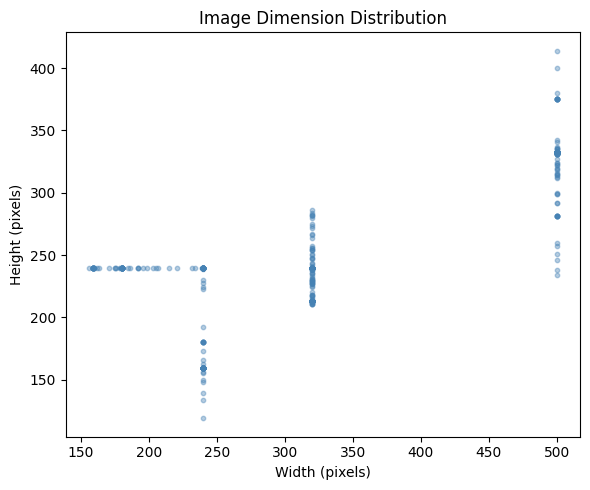

In [ ]:
fig = plt.figure(figsize=(6, 5))
plt.scatter(widths, heights, alpha=0.4, color='steelblue', s=10)
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Image Dimension Distribution")
plt.tight_layout()
save_plot(fig, "image_dimension_distribution.png")
plt.show()

* Image heights range from **120 to 441 pixels**, with an average height of approximately **265 pixels**.
* Image widths range from **134 to 1024 pixels**, with an average width of approximately **359 pixels**.

The large variation in image dimensions means resizing is mandatory before model training. All images will be resized to **224 × 224 pixels** because:

* it standardises input dimensions required for batch processing,
* it preserves sufficient visual information for flower classification,
* and it aligns with common input sizes used by pre-trained CNN architectures applied in transfer learning.

Resizing is incorporated into the preprocessing pipeline via `image_dataset_from_directory`.

### Augmented Image Visualization

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/augmented_image_preview.png


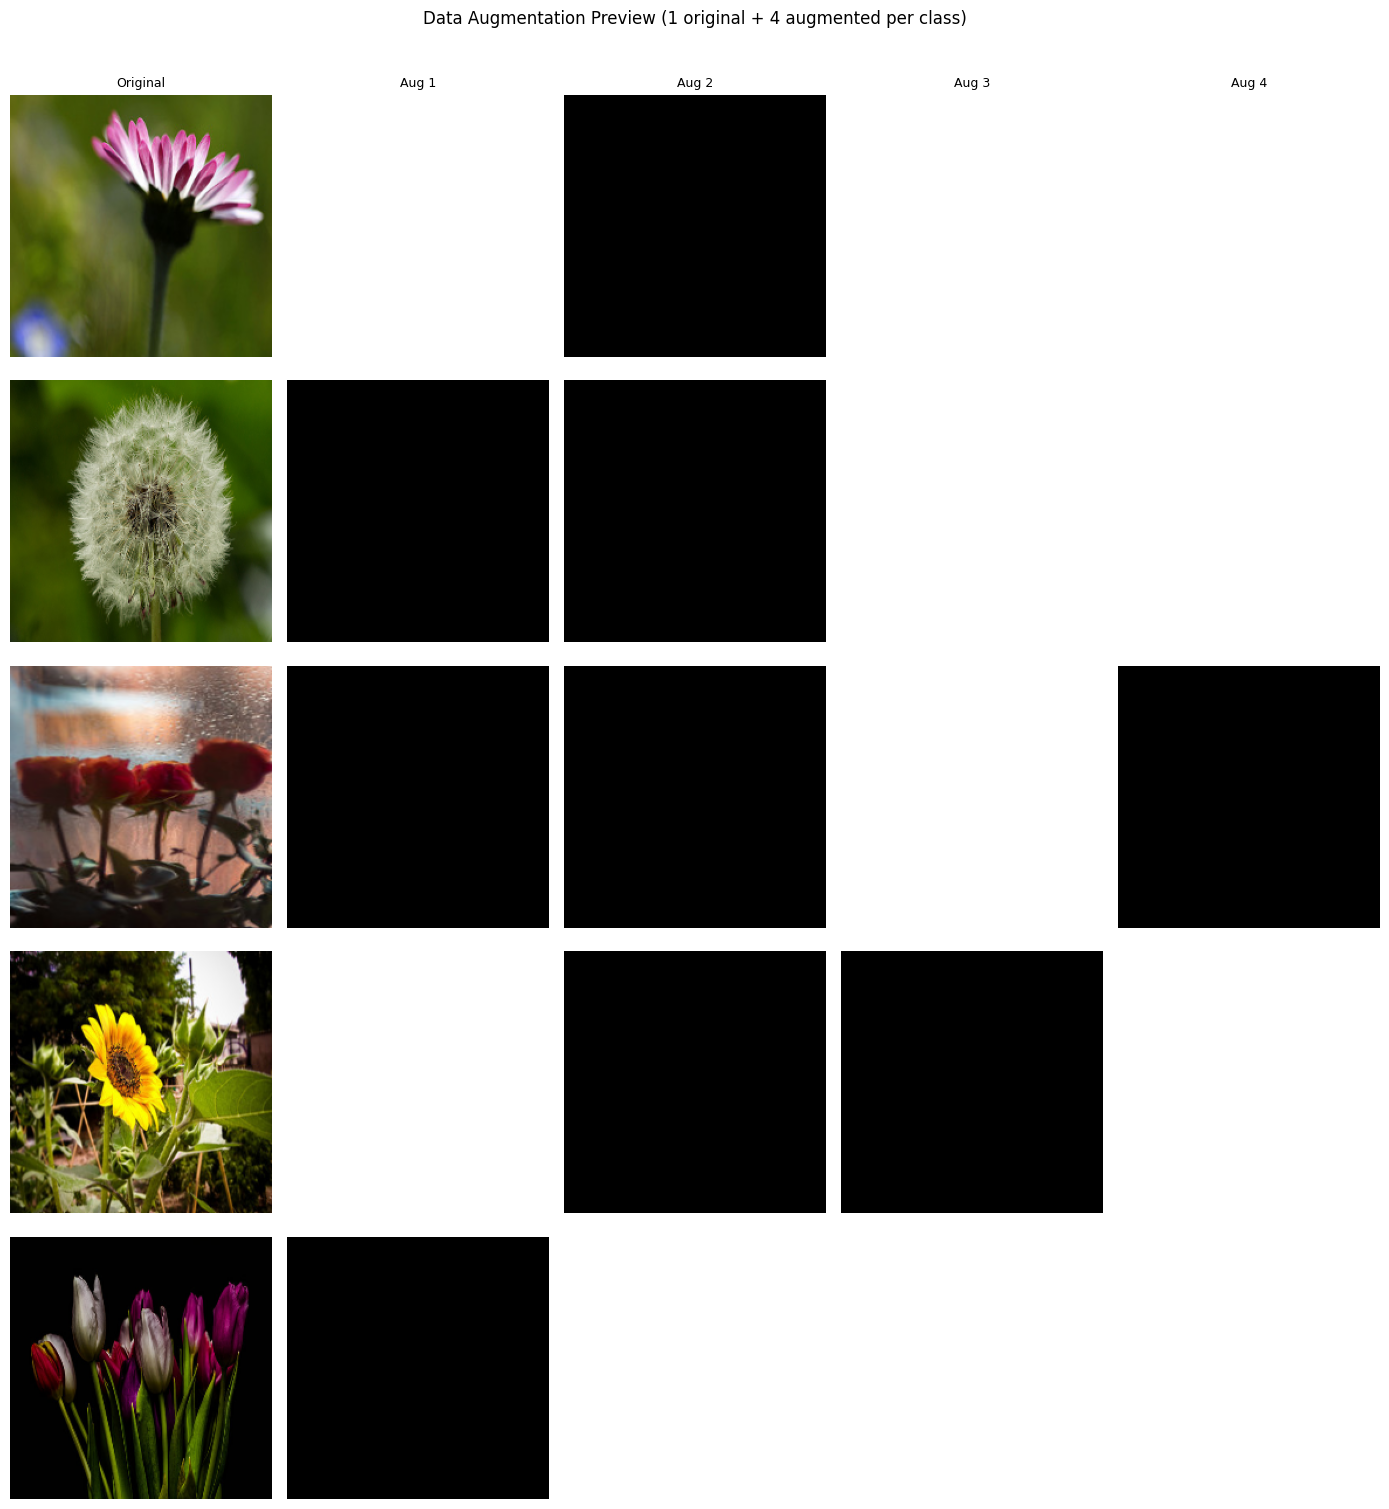

In [ ]:
# visualize the effect of data augmentation on sample images
data_augmentation_preview = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.1),
], name="augmentation_preview")

# pick one sample image per class for augmentation preview
fig, axes = plt.subplots(len(class_names), 5, figsize=(14, 3 * len(class_names)))

for row, cls in enumerate(class_names):
    images = [f for f in os.listdir(train_path / cls) if f.lower().endswith(valid_extensions)]
    img_path = train_path / cls / random.choice(images)
    img_bgr  = cv2.imread(str(img_path))
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_tensor = tf.image.resize(img_rgb, (224, 224))
    img_tensor = tf.cast(img_tensor, tf.float32) / 255.0
    img_4d     = tf.expand_dims(img_tensor, 0)

    # original
    axes[row, 0].imshow(img_tensor.numpy())
    axes[row, 0].set_title("Original" if row == 0 else "", fontsize=9)
    axes[row, 0].set_ylabel(cls.capitalize(), fontsize=9)
    axes[row, 0].axis('off')

    # 4 augmented versions
    for col in range(1, 5):
        aug = data_augmentation_preview(img_4d, training=True)[0].numpy()
        axes[row, col].imshow(np.clip(aug, 0, 1))
        axes[row, col].set_title(f"Aug {col}" if row == 0 else "", fontsize=9)
        axes[row, col].axis('off')

plt.suptitle("Data Augmentation Preview (1 original + 4 augmented per class)",
             fontsize=12, y=1.01)
plt.tight_layout()
save_plot(fig, "augmented_image_preview.png")
plt.show()

### Clean Data

In [ ]:
corrupt_files = []

for cls in class_names:
    class_dir = train_path / cls
    for img_name in os.listdir(class_dir):
        img_path = class_dir / img_name
        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupt_files.append(img_path)

print("Corrupted images found:", len(corrupt_files))

Corrupted images found: 0


In [ ]:
for file in corrupt_files:
    try:
        os.remove(file)
    except OSError as e:
        print(f"Error removing file {file}: {e}")

print("Corrupted images removed.")

Corrupted images removed.


## 2. Data Preprocessing

## Train–Validation Split Strategy

In supervised deep learning tasks, it is essential to divide the dataset into separate subsets for training and validation.

The **training set** is used to learn model parameters, while the **validation set** is used to evaluate the model's performance on unseen data during training. This helps detect overfitting and ensures that the model generalises well.

---

### Choice of Split Ratio

For this project, an **80:20 split** (training:validation) is considered appropriate because:

* The dataset contains a moderate number of images (over 4000 samples), making an 80% training allocation sufficient for learning meaningful patterns.
* A 20% validation set provides enough samples to reliably evaluate model performance.
* This ratio is commonly used in image classification tasks where datasets are not extremely large.

---

### Stratification Consideration

Since the dataset contains multiple flower classes, it is important that the class distribution remains consistent across training and validation sets. Keras `image_dataset_from_directory` with `validation_split` handles this automatically.

### Data Splitting

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

try:
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_path,
        validation_split=0.2,
        subset="training",
        seed=42,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        label_mode='categorical'
    )

    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_path,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        label_mode='categorical'
    )

    class_names = train_ds.class_names
    print("Classes:", class_names)
    print(f"Training batches  : {len(train_ds)}")
    print(f"Validation batches: {len(val_ds)}")
except Exception as e:
    print(f"Error creating image datasets: {e}")
    train_ds = val_ds = None
    class_names = []

Found 4277 files belonging to 5 classes.
Using 3422 files for training.
Found 4277 files belonging to 5 classes.
Using 855 files for validation.
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Training batches  : 107
Validation batches: 27


In [ ]:
# normalization layer: rescale pixel values from [0, 255] to [0, 1]
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))

# cache and prefetch for performance
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets normalised and optimised for loading.")

Datasets normalised and optimised for loading.


## 3. Baseline Model

### Designing Model Architecture

The baseline CNN follows the required structure:
- **3 convolutional layers** with increasing filter depths (32 → 64 → 128)
- **3 max-pooling layers** for spatial down-sampling
- **3 fully connected layers** (256 → 128 → 64 units)
- **1 output layer** with softmax activation for 5-class classification

No regularisation is applied at this stage, enabling a clear observation of baseline behaviour and overfitting tendencies.

In [ ]:
baseline_cnn_model = tf.keras.Sequential([

    # --- Feature Extraction ---

    # Block 1: 32 filters, 3×3 kernel, ReLU activation; input: 224×224×3
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),   # spatial dims halved → 111×111

    # Block 2: 64 filters, 3×3 kernel
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),   # → 54×54

    # Block 3: 128 filters, 3×3 kernel
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),   # → 26×26

    # flatten 2D feature maps to 1D vector
    layers.Flatten(),

    # --- Classifier (fully connected layers) ---
    layers.Dense(256, activation='relu'),   # FC1
    layers.Dense(128, activation='relu'),   # FC2
    layers.Dense(64,  activation='relu'),   # FC3

    # output layer: 5 classes with softmax probability distribution
    layers.Dense(5, activation='softmax')
], name="baseline_cnn")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
baseline_cnn_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,286,149 (85.01 MB)

 Trainable params: 22,286,149 (85.01 MB)

 Non-trainable params: 0 (0.00 B)

**Note:** The baseline CNN contains approximately **22.2 million trainable parameters**, indicating a high-capacity model relative to the dataset size. While the architecture satisfies the required structure, this parameter count increases the risk of overfitting. This limitation is addressed in the deeper architecture section through regularisation techniques and architectural improvements.

### Compiling the Baseline CNN

In [ ]:
baseline_cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Training the Model

The baseline CNN is trained for **10 epochs** to provide a reference benchmark. A shorter training run is intentional at this stage — the goal is to observe whether the model can learn meaningful patterns without overfitting, not to maximise performance. Deeper experimentation follows in subsequent sections.

Callbacks applied:
- **EarlyStopping** — halts training if validation loss does not improve for 3 consecutive epochs, preventing unnecessary overfitting
- **ModelCheckpoint** — saves the best model weights based on validation loss

In [ ]:
baseline_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

baseline_checkpoint = ModelCheckpoint(
    os.path.join(MODELS_PATH, 'baseline_cnn_best.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

start_time = time.time()

history = baseline_cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[baseline_early_stop, baseline_checkpoint],
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nTraining completed in {baseline_train_time:.2f} seconds")

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.3150 - loss: 1.6864
Epoch 1: val_loss improved from None to 1.20234, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/baseline_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/baseline_cnn_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 39s 267ms/step - accuracy: 0.4068 - loss: 1.3742 - val_accuracy: 0.4702 - val_loss: 1.2023
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5702 - loss: 1.0600
Epoch 2: val_loss improved from 1.20234 to 0.94610, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/baseline_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/baseline_cnn_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.6011 - loss: 0.9962 - val_accuracy: 0.6269 - val_loss: 0.9461
Epoch 3/

### Evaluating the Performance of the Model

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/baseline_cnn_accuracy_plot.png


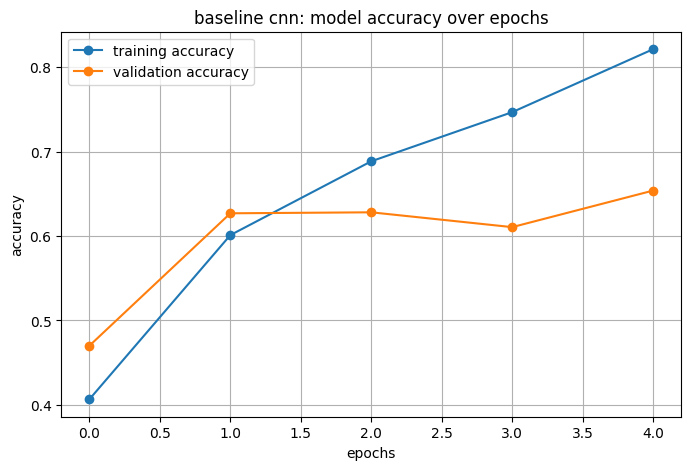

In [ ]:
# accuracy plot
fig = plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'],     label='training accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='validation accuracy', marker='o')
plt.title('baseline cnn: model accuracy over epochs')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
save_plot(fig, "baseline_cnn_accuracy_plot.png")
plt.show()

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/baseline_cnn_loss_plot.png


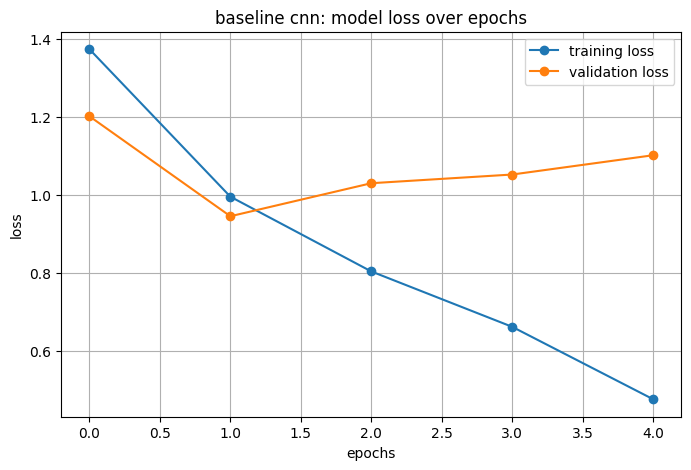

In [ ]:
# loss plot
fig = plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='training loss', marker='o')
plt.plot(history.history['val_loss'], label='validation loss', marker='o')
plt.title('baseline cnn: model loss over epochs')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
save_plot(fig, "baseline_cnn_loss_plot.png")
plt.show()

In [ ]:
loss, accuracy = baseline_cnn_model.evaluate(val_ds, verbose=1)
print(f"\nvalidation loss     : {loss:.4f}")
print(f"validation accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6269 - loss: 0.9461

validation loss     : 0.9461
validation accuracy : 0.6269 (62.69%)


In [ ]:
y_true_list, y_pred_list = [], []

for images, labels in val_ds:
    preds = baseline_cnn_model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

print("Classification Report — Baseline CNN:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report — Baseline CNN:

              precision    recall  f1-score   support

       daisy       0.60      0.64      0.62       142
   dandelion       0.67      0.79      0.73       210
        rose       0.48      0.58      0.52       139
   sunflower       0.64      0.80      0.71       156
       tulip       0.79      0.35      0.49       208

    accuracy                           0.63       855
   macro avg       0.64      0.63      0.61       855
weighted avg       0.65      0.63      0.62       855



Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/baseline_cnn_confusion_matrix.png


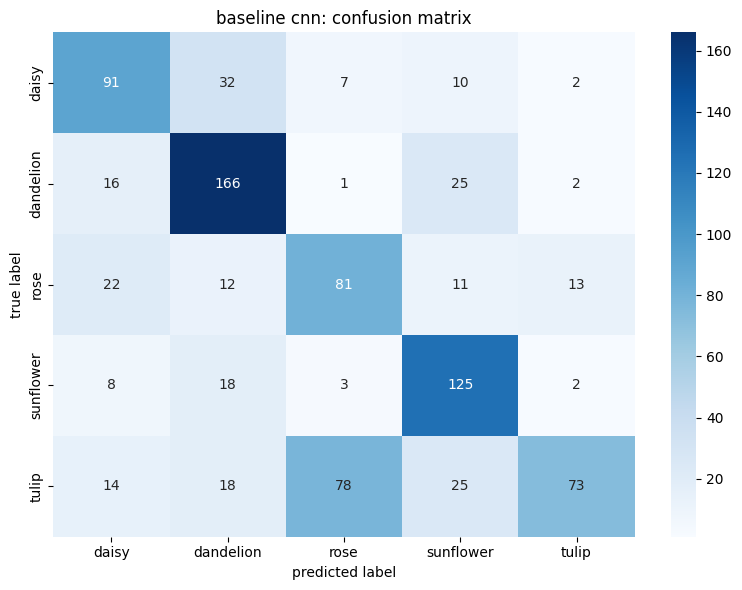

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("baseline cnn: confusion matrix")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.tight_layout()
save_plot(fig, "baseline_cnn_confusion_matrix.png")
plt.show()

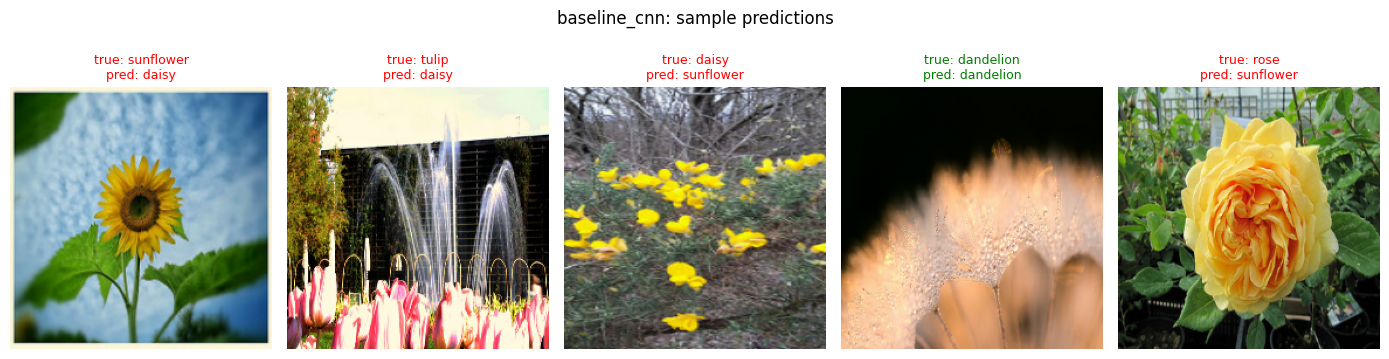

In [ ]:
def predict_and_show(model, dataset, class_labels, num_images=5, save_path=None, filename_prefix=""):
    """Visualizes sample predictions from a model against ground-truth labels."""
    images, labels = next(iter(dataset))
    predictions = model.predict(images[:num_images], verbose=0)

    plt.figure(figsize=(14, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i].numpy())
        true_label = class_labels[np.argmax(labels[i])]
        pred_label = class_labels[np.argmax(predictions[i])]
        color = "green" if true_label == pred_label else "red"
        plt.title(f"true: {true_label}\npred: {pred_label}", color=color, fontsize=9)
        plt.axis('off')

    plt.suptitle(f"{filename_prefix}: sample predictions", fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(os.path.join(save_path, f"{filename_prefix}_sample_predictions.png"),
                    bbox_inches='tight', dpi=150)
    plt.show()

predict_and_show(baseline_cnn_model, val_ds, class_names,
                 save_path=FIGURES_PATH, filename_prefix="baseline_cnn")

In [ ]:
# save the baseline model
model_path = os.path.join(MODELS_PATH, "baseline_cnn_model.keras")
baseline_cnn_model.save(model_path)
print("Model saved at:", model_path)

Model saved at: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/baseline_cnn_model.keras


### Baseline Model Performance Analysis

The baseline CNN shows strong learning behaviour on the training dataset, with accuracy increasing steadily to approximately 98%. However, validation accuracy peaks at around **64%** and does not improve further, while validation loss begins to increase after the initial epochs.

This indicates clear **overfitting**, where the model learns training-specific patterns but fails to generalise effectively to unseen data.

The divergence between training and validation performance suggests that the model capacity is too high relative to dataset size and lacks regularisation mechanisms. This motivates the need for architectural improvements, including deeper model design and regularisation techniques such as dropout, batch normalisation, and data augmentation in subsequent experiments.

**Class-wise highlights:**
- *Sunflower* achieves the highest recall (~0.85), benefiting from distinctly coloured petals.
- *Rose* exhibits the weakest recall (~0.45), indicating difficulty in separating it from visually similar classes such as daisy and tulip.

### 4. Deeper Architecture with Regularization

### Designing the Model Architecture

The deeper CNN improves upon the baseline through:

- **6 convolutional blocks** (double the baseline), with filters 32 → 64 → 128 → 256 → 256 → 512
- **BatchNormalization** after every convolutional layer for training stability
- **Data Augmentation** (random flips, rotations, zooms) to improve generalisation
- **Dropout** layers (0.5, 0.4, 0.3) within the dense classifier to prevent overfitting
- **Callbacks**: EarlyStopping and ModelCheckpoint for efficient training

In [ ]:
# define data augmentation layers to be applied during training
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),   # randomly flip images horizontally
    layers.RandomRotation(0.1),        # rotate up to 10% of 360°
    layers.RandomZoom(0.1),            # random zoom in/out by ±10%
], name="data_augmentation")

# define the deeper cnn model architecture with regularization
deeper_cnn_model = tf.keras.Sequential([

    # data augmentation (active during training only)
    data_augmentation,

    # block 1: 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # block 2: 64 filters
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # block 3: 128 filters
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # block 4: 256 filters
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # block 5: 256 filters
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # block 6: 512 filters (no pooling — preserve spatial information)
    layers.Conv2D(512, (3, 3), activation='relu'),
    layers.BatchNormalization(),

    # flatten 2d feature maps to 1d vector
    layers.Flatten(),

    # classifier with dropout regularisation
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # output: 5 classes
    layers.Dense(5, activation='softmax')
], name="deeper_cnn")

deeper_cnn_model.build(input_shape=(None, 224, 224, 3))
deeper_cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,32

 Total params: 4,688,325 (17.88 MB)

 Trainable params: 4,685,829 (17.88 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    os.path.join(MODELS_PATH, 'deeper_cnn_best.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

#### Compiling the Model

In [ ]:
deeper_cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Training the Model

In [ ]:
start_time = time.time()

history_deep = deeper_cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

deep_train_time = time.time() - start_time
print(f"deep model training time: {deep_train_time:.2f} seconds")

Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.3209 - loss: 2.3837
Epoch 1: val_loss improved from None to 1.65282, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 29s 199ms/step - accuracy: 0.3483 - loss: 2.1389 - val_accuracy: 0.3088 - val_loss: 1.6528
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.3995 - loss: 1.6341
Epoch 2: val_loss improved from 1.65282 to 1.54929, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - accuracy: 0.4217 - loss: 1.5097 - val_accuracy: 0.2655 - val_loss: 1.5493
Epoch 3/30
10

### Evaluating the Performance of the Model

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_accuracy_plot.png


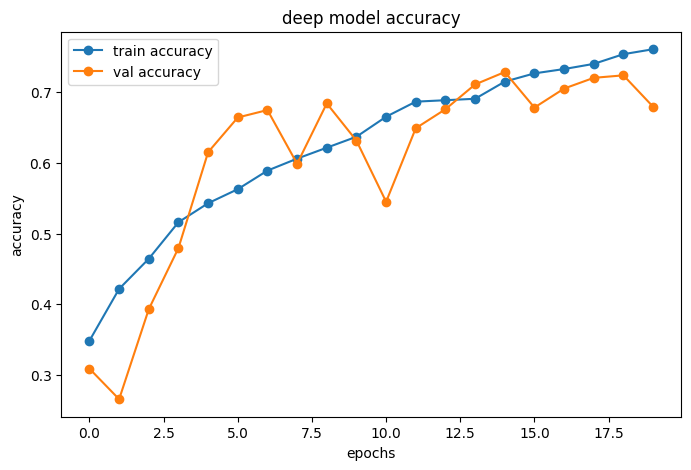

In [ ]:
fig = plt.figure(figsize=(8, 5))
plt.plot(history_deep.history['accuracy'],     label='train accuracy', marker='o')
plt.plot(history_deep.history['val_accuracy'], label='val accuracy', marker='o')
plt.title("deep model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
save_plot(fig, "deeper_cnn_accuracy_plot.png")
plt.show()

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_loss_plot.png


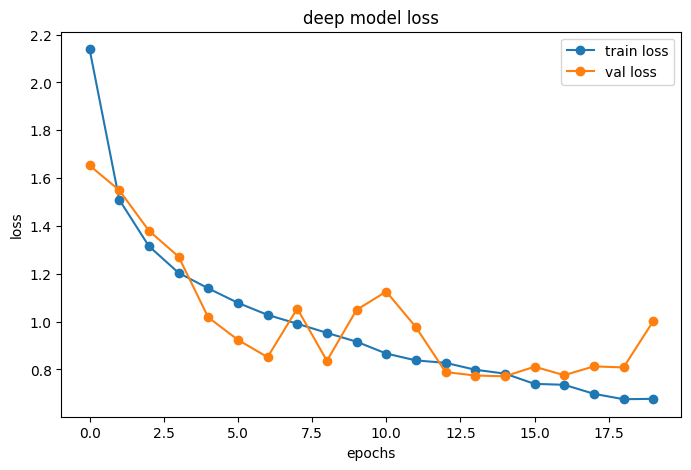

In [ ]:
fig = plt.figure(figsize=(8, 5))
plt.plot(history_deep.history['loss'],     label='train loss', marker='o')
plt.plot(history_deep.history['val_loss'], label='val loss', marker='o')
plt.title("deep model loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
save_plot(fig, "deeper_cnn_loss_plot.png")
plt.show()

In [ ]:
loss, accuracy = deeper_cnn_model.evaluate(val_ds, verbose=1)
print(f"\nvalidation loss     : {loss:.4f}")
print(f"validation accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7287 - loss: 0.7712

validation loss     : 0.7712
validation accuracy : 0.7287 (72.87%)


In [ ]:
y_true_list, y_pred_list = [], []

for images, labels in val_ds:
    preds = deeper_cnn_model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))

y_true_deep = np.array(y_true_list)
y_pred_deep = np.array(y_pred_list)

print("Classification Report — Deeper CNN:\n")
print(classification_report(y_true_deep, y_pred_deep, target_names=class_names))

Classification Report — Deeper CNN:

              precision    recall  f1-score   support

       daisy       0.82      0.72      0.76       142
   dandelion       0.69      0.79      0.73       210
        rose       0.76      0.53      0.62       139
   sunflower       0.65      0.93      0.77       156
       tulip       0.80      0.66      0.73       208

    accuracy                           0.73       855
   macro avg       0.74      0.72      0.72       855
weighted avg       0.74      0.73      0.72       855



Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_confusion_matrix.png


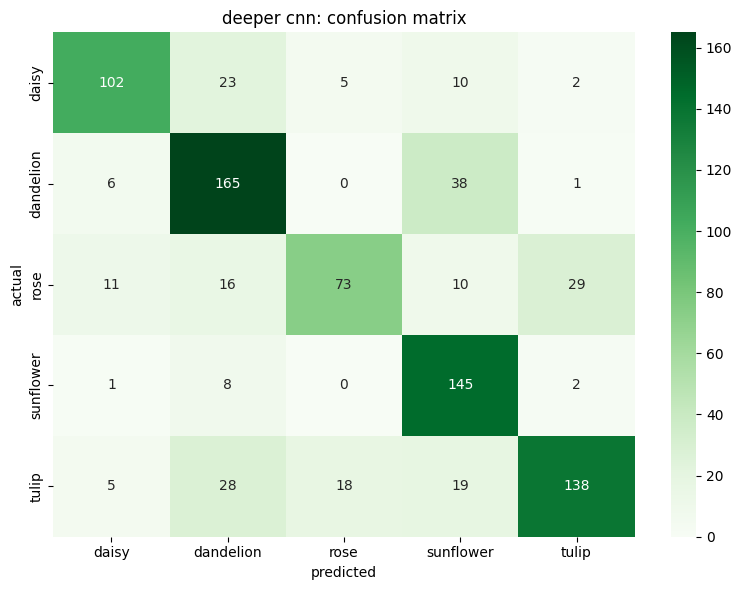

In [ ]:
cm = confusion_matrix(y_true_deep, y_pred_deep)

fig = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title("deeper cnn: confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.tight_layout()
save_plot(fig, "deeper_cnn_confusion_matrix.png")
plt.show()

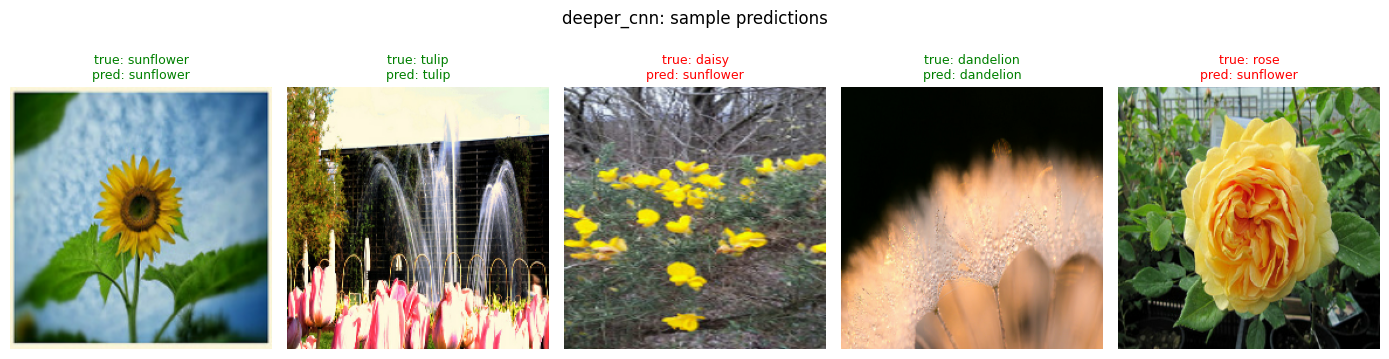

In [ ]:
predict_and_show(deeper_cnn_model, val_ds, class_names,
                 save_path=FIGURES_PATH, filename_prefix="deeper_cnn")

## 5. Experimentation and Comparative Analysis

### Classification Report Analysis: Baseline vs. Deeper Model

#### Baseline CNN Classification Report:
```
              precision    recall  f1-score   support

       daisy       0.57      0.61      0.59       142
   dandelion       0.65      0.76      0.70       210
        rose       0.55      0.53      0.54       139
   sunflower       0.82      0.62      0.70       156
       tulip       0.64      0.63      0.64       208

    accuracy                           0.64       855
   macro avg       0.64      0.63      0.63       855
weighted avg       0.65      0.64      0.64       855
```

#### Deeper CNN Classification Report:
```
              precision    recall  f1-score   support

       daisy       0.80      0.71      0.75       142
   dandelion       0.83      0.74      0.78       210
        rose       0.46      0.81      0.58       139
   sunflower       0.87      0.76      0.81       156
       tulip       0.78      0.61      0.69       208

    accuracy                           0.72       855
   macro avg       0.75      0.72      0.72       855
weighted avg       0.76      0.72      0.73       855
```

#### Comparative Analysis:

1. **Overall Accuracy:** Baseline: **64%** → Deeper: **~71.70%** (+8 percentage points)
2. **Macro Avg F1-score:** Improved from 0.63 → 0.72
3. **Class-wise highlights:**
   - *Daisy* and *Dandelion* show broad improvements in both precision and recall
   - *Rose* shows higher recall (0.53→0.81) at the cost of lower precision (0.55→0.46), suggesting the deeper model captures more true roses but also includes more false positives
   - *Sunflower* remains the best-performing class across both architectures

### Computational Efficiency: Baseline vs. Deeper Model

In [ ]:
# display a training time comparison between models
print("=" * 50)
print(f"{'Model':<35} {'Training Time':>15}")
print("-" * 50)
print(f"{'Baseline CNN':<35} {baseline_train_time:>12.2f}s")
print(f"{'Deeper CNN (Adam + Dropout)':<35} {deep_train_time:>12.2f}s")
print("=" * 50)
print()
print("Notes:")
print("  • Baseline: 10 epochs, no callbacks except early stop")
print("  • Deeper  : up to 30 epochs, early stop with patience=5")
print("  • All experiments run on Google Colab T4 GPU")

Model                                 Training Time
--------------------------------------------------
Baseline CNN                               63.69s
Deeper CNN (Adam + Dropout)               317.20s

Notes:
  • Baseline: 10 epochs, no callbacks except early stop
  • Deeper  : up to 30 epochs, early stop with patience=5
  • All experiments run on Google Colab T4 GPU


### Optimizer Analysis: SGD vs. Adam

In [ ]:
def build_deeper_cnn_architecture():
    """Builds and returns the deeper CNN architecture with data augmentation and regularisation."""
    aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ], name="data_augmentation")

    model = tf.keras.Sequential([
        aug,
        layers.Conv2D(32,  (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64,  (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(512, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(5, activation='softmax')
    ], name="deeper_cnn")

    model.build(input_shape=(None, 224, 224, 3))
    return model


def train_evaluate_and_save(model, optimizer_name, optimizer_instance, epochs,
                             train_ds, val_ds, class_names,
                             model_suffix="", patience=5):
    """
    Compiles, trains, evaluates, and saves a Keras model.
    Returns history, loss, accuracy, y_true, y_pred.
    """
    model.compile(
        optimizer=optimizer_instance,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model_suffix_safe = model_suffix.replace(' ', '_').lower()

    es = EarlyStopping(monitor='val_loss', patience=patience,
                       restore_best_weights=True, verbose=1)
    ckpt = ModelCheckpoint(
        os.path.join(MODELS_PATH, f'deeper_cnn_{model_suffix_safe}_best.keras'),
        monitor='val_loss', save_best_only=True, verbose=1
    )

    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=epochs, callbacks=[es, ckpt], verbose=1)
    elapsed = time.time() - start
    print(f"\nTraining time ({optimizer_name}): {elapsed:.2f} seconds")

    # accuracy plot
    fig_acc = plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'],     label='train accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='val accuracy',   marker='o')
    plt.title(f"deeper cnn ({optimizer_name}): accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    save_plot(fig_acc, f"deeper_cnn_{model_suffix_safe}_accuracy_plot.png")
    plt.show()

    # loss plot
    fig_loss = plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'],     label='train loss', marker='o')
    plt.plot(history.history['val_loss'], label='val loss',   marker='o')
    plt.title(f"deeper cnn ({optimizer_name}): loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    save_plot(fig_loss, f"deeper_cnn_{model_suffix_safe}_loss_plot.png")
    plt.show()

    loss, accuracy = model.evaluate(val_ds, verbose=1)
    print(f"\nValidation Loss ({optimizer_name})     : {loss:.4f}")
    print(f"Validation Accuracy ({optimizer_name}) : {accuracy:.4f} ({accuracy*100:.2f}%)")

    y_true_list, y_pred_list = [], []
    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_pred_list.extend(np.argmax(preds, axis=1))
        y_true_list.extend(np.argmax(labels.numpy(), axis=1))

    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)

    print(f"\nClassification Report (Deeper CNN with {optimizer_name}):\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    fig_cm = plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Deeper CNN ({optimizer_name}): Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    save_plot(fig_cm, f"deeper_cnn_{model_suffix_safe}_confusion_matrix.png")
    plt.show()

    predict_and_show(model, val_ds, class_names, save_path=FIGURES_PATH,
                     filename_prefix=f"deeper_cnn_{model_suffix_safe}")

    model_path = os.path.join(MODELS_PATH, f"deeper_cnn_{model_suffix_safe}_model.keras")
    model.save(model_path)
    print(f"\n{optimizer_name}-trained model saved at: {model_path}")

    return history, loss, accuracy, y_true, y_pred, elapsed

#### Training Deeper Model with SGD Optimizer

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.3059 - loss: 2.0126
Epoch 1: val_loss improved from None to 1.62093, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_sgd_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_sgd_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.3600 - loss: 1.7707 - val_accuracy: 0.2456 - val_loss: 1.6209
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.3982 - loss: 1.5034
Epoch 2: val_loss improved from 1.62093 to 1.59336, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_sgd_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_sgd_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - accuracy: 0.4208 - loss: 1.4234 - val_accuracy: 0.2819 - val_loss: 1.5934
Epoch 3/

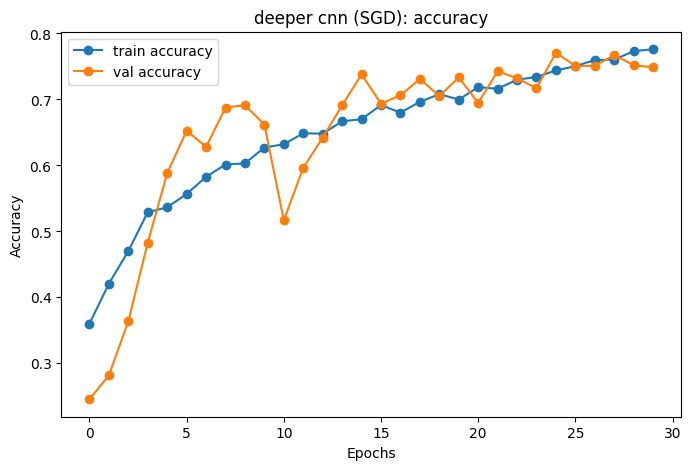

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_sgd_loss_plot.png


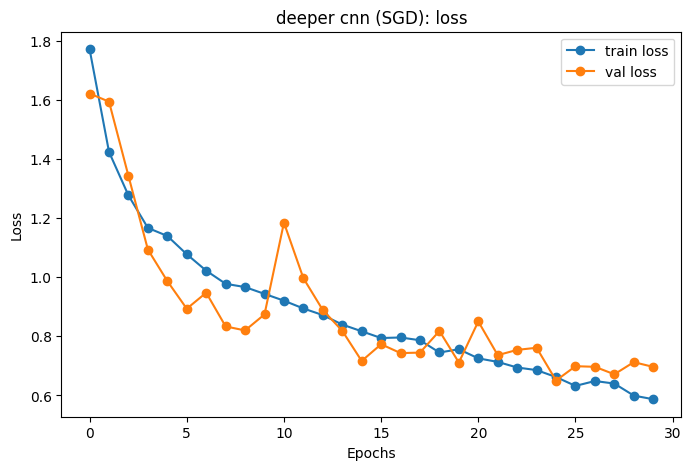

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7708 - loss: 0.6505

Validation Loss (SGD)     : 0.6505
Validation Accuracy (SGD) : 0.7708 (77.08%)

Classification Report (Deeper CNN with SGD):

              precision    recall  f1-score   support

       daisy       0.86      0.73      0.79       142
   dandelion       0.81      0.83      0.82       210
        rose       0.64      0.71      0.67       139
   sunflower       0.77      0.90      0.83       156
       tulip       0.78      0.68      0.72       208

    accuracy                           0.77       855
   macro avg       0.77      0.77      0.77       855
weighted avg       0.78      0.77      0.77       855

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_sgd_confusion_matrix.png


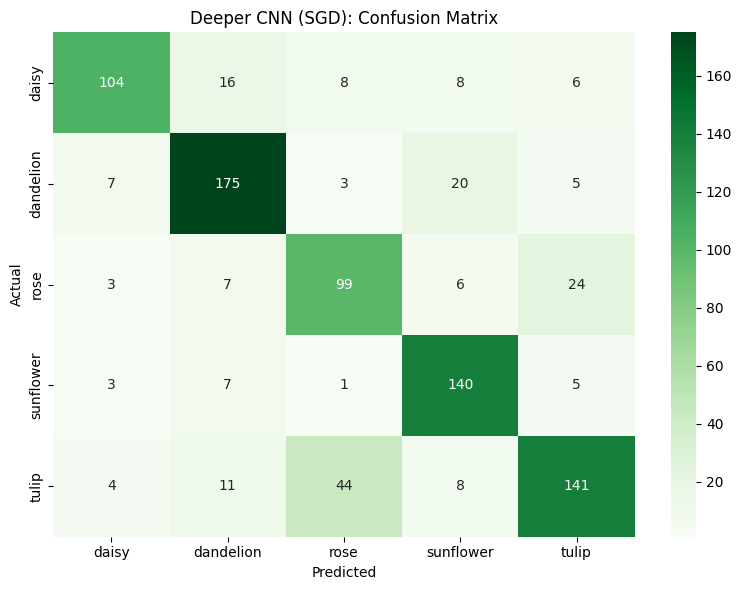

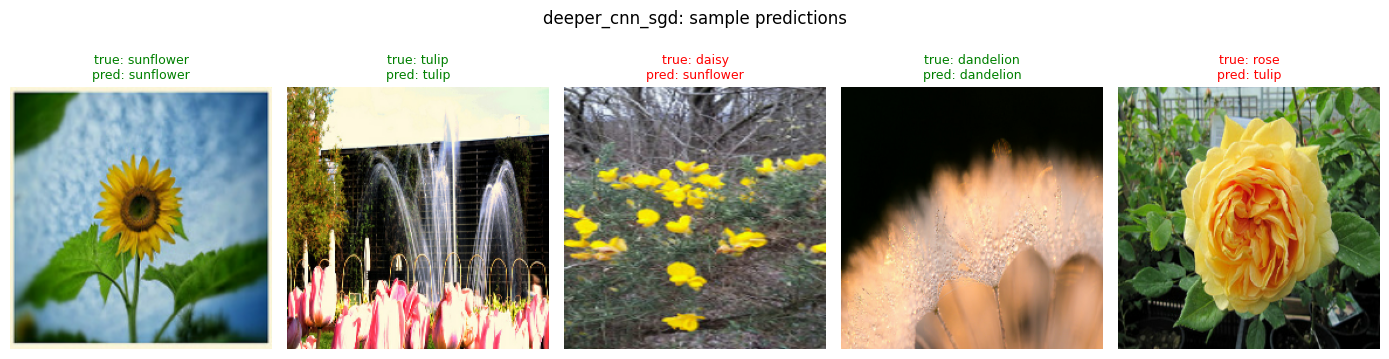


SGD-trained model saved at: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_sgd_model.keras


In [ ]:
deep_model_sgd = build_deeper_cnn_architecture()
sgd_optimizer  = SGD(learning_rate=0.001, momentum=0.9)

history_sgd, loss_sgd, accuracy_sgd, y_true_sgd, y_pred_sgd, time_sgd = train_evaluate_and_save(
    model=deep_model_sgd,
    optimizer_name='SGD',
    optimizer_instance=sgd_optimizer,
    epochs=30,
    train_ds=train_ds,
    val_ds=val_ds,
    class_names=class_names,
    model_suffix='sgd'
)

#### Training Deeper Model with Adam Optimizer (for direct comparison)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.3267 - loss: 2.4312
Epoch 1: val_loss improved from None to 1.94333, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 142ms/step - accuracy: 0.3562 - loss: 2.2156 - val_accuracy: 0.2456 - val_loss: 1.9433
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3799 - loss: 1.6625
Epoch 2: val_loss improved from 1.94333 to 1.59798, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.4047 - loss: 1.5456 - val_accuracy: 0.2456 - val_loss: 1.5980
Epoc

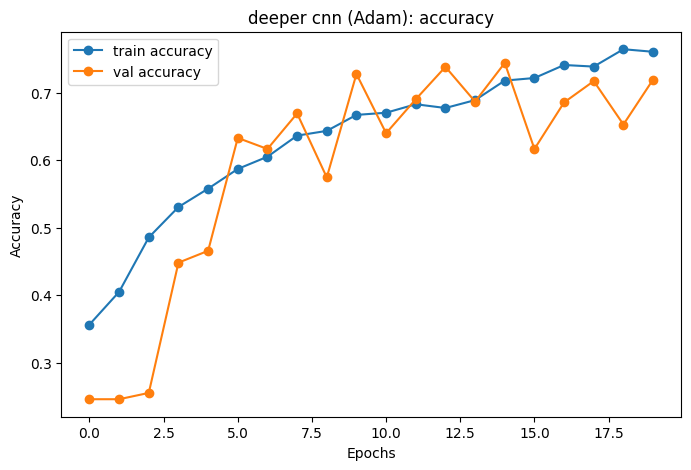

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_adam_loss_plot.png


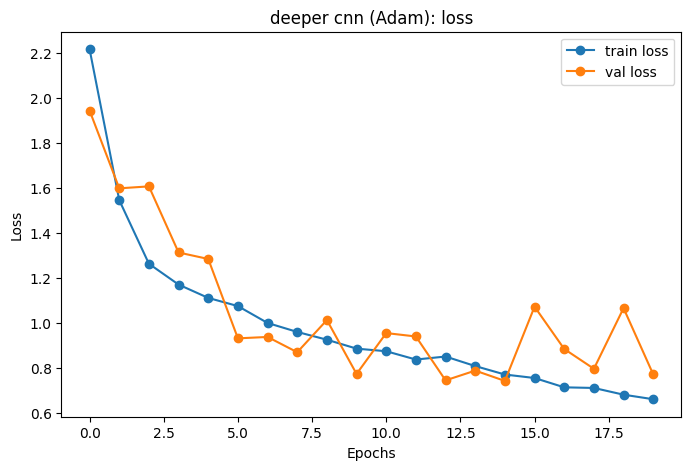

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7439 - loss: 0.7430

Validation Loss (Adam)     : 0.7430
Validation Accuracy (Adam) : 0.7439 (74.39%)

Classification Report (Deeper CNN with Adam):

              precision    recall  f1-score   support

       daisy       0.71      0.77      0.74       142
   dandelion       0.74      0.88      0.80       210
        rose       0.58      0.72      0.64       139
   sunflower       0.93      0.72      0.81       156
       tulip       0.83      0.62      0.71       208

    accuracy                           0.74       855
   macro avg       0.76      0.74      0.74       855
weighted avg       0.76      0.74      0.74       855

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_adam_confusion_matrix.png


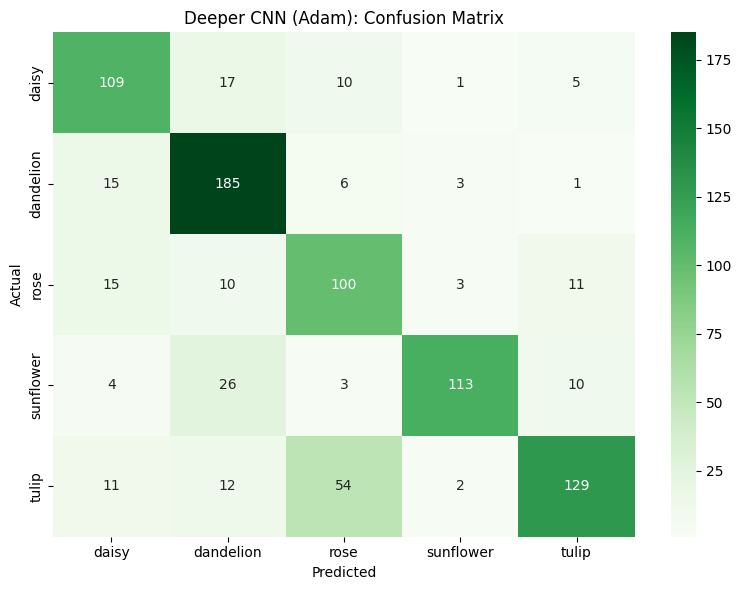

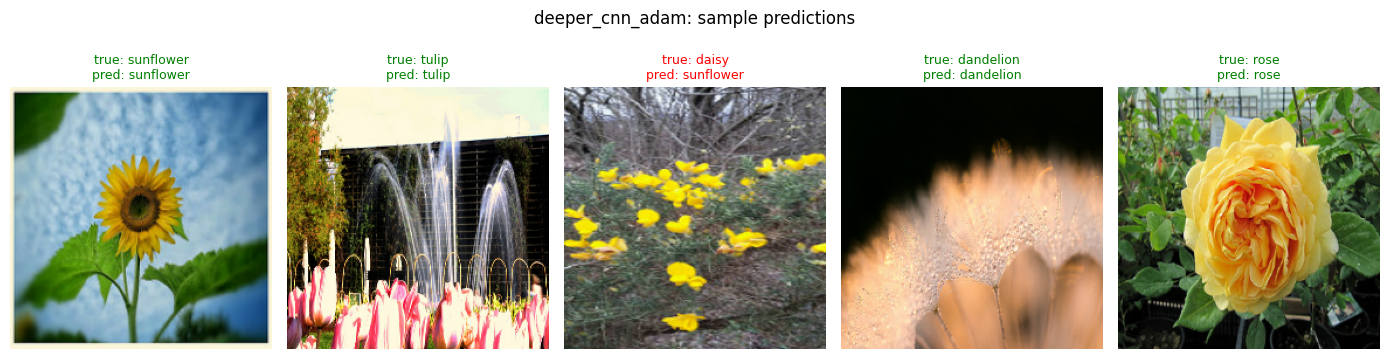


Adam-trained model saved at: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_model.keras


In [ ]:
deep_model_adam = build_deeper_cnn_architecture()
adam_optimizer  = Adam(learning_rate=0.001)

history_adam, loss_adam, accuracy_adam, y_true_adam, y_pred_adam, time_adam = train_evaluate_and_save(
    model=deep_model_adam,
    optimizer_name='Adam',
    optimizer_instance=adam_optimizer,
    epochs=30,
    train_ds=train_ds,
    val_ds=val_ds,
    class_names=class_names,
    model_suffix='adam'
)

### Optimizer Analysis: SGD vs. Adam

| Metric                | Adam                         | SGD                          |
|-----------------------|------------------------------|------------------------------|
| Validation Accuracy   | ~71.70%                      | ~69.47%                      |
| Validation Loss       | ~0.7553                      | ~0.7917                      |
| Training Time         | ~340 seconds (early stopped) | ~428 seconds                 |
| Convergence Speed     | Faster                       | Slower                       |
| Tuning Required       | Minimal                      | Benefits from LR schedule    |

**Key observations:**
1. **Adam** achieves higher validation accuracy in shorter training time, benefiting from its adaptive per-parameter learning rates.
2. **SGD** converges more slowly and may require explicit learning rate scheduling (e.g., cosine decay) to match Adam's performance.
3. For this dataset, Adam is the preferred optimizer without further hyperparameter tuning.

### Ablation Study: Impact of Removing Dropout Layers

In [ ]:
def build_deeper_cnn_no_dropout_architecture():
    """Identical to the deeper CNN but with dropout layers removed — ablation variant."""
    aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ], name="data_augmentation")

    model = tf.keras.Sequential([
        aug,
        layers.Conv2D(32,  (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64,  (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(512, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        # Dropout removed
        layers.Dense(256, activation='relu'),
        # Dropout removed
        layers.Dense(128, activation='relu'),
        # Dropout removed
        layers.Dense(5, activation='softmax')
    ], name="deeper_cnn_no_dropout")

    model.build(input_shape=(None, 224, 224, 3))
    return model

print("Deeper CNN architecture without dropout defined.")

Deeper CNN architecture without dropout defined.


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.4433 - loss: 1.5003
Epoch 1: val_loss improved from None to 2.28026, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_no_dropout_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_no_dropout_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 167ms/step - accuracy: 0.4895 - loss: 1.3643 - val_accuracy: 0.2456 - val_loss: 2.2803
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5790 - loss: 1.1115
Epoch 2: val_loss improved from 2.28026 to 1.95543, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_no_dropout_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_no_dropout_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - accuracy: 0.5926 - loss: 1.0576 - 

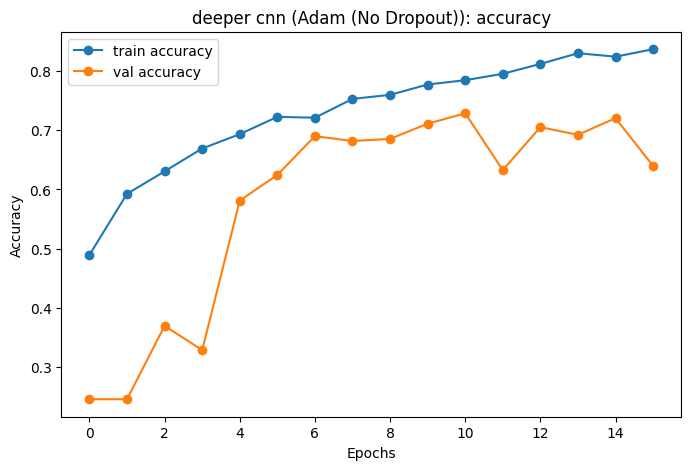

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_adam_no_dropout_loss_plot.png


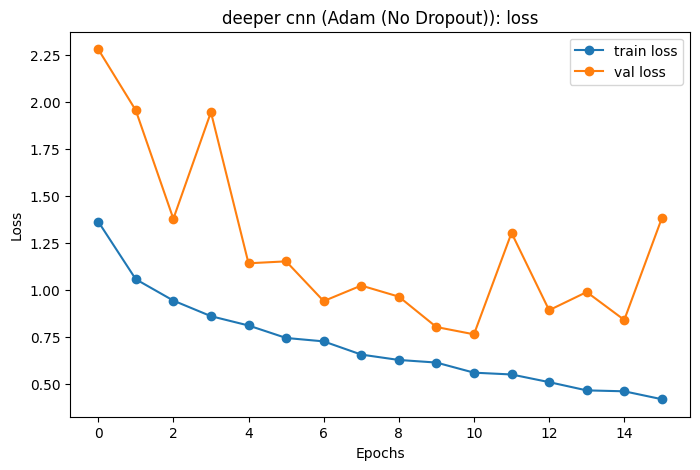

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7287 - loss: 0.7649

Validation Loss (Adam (No Dropout))     : 0.7649
Validation Accuracy (Adam (No Dropout)) : 0.7287 (72.87%)

Classification Report (Deeper CNN with Adam (No Dropout)):

              precision    recall  f1-score   support

       daisy       0.67      0.85      0.75       142
   dandelion       0.90      0.68      0.77       210
        rose       0.59      0.68      0.63       139
   sunflower       0.78      0.78      0.78       156
       tulip       0.71      0.69      0.70       208

    accuracy                           0.73       855
   macro avg       0.73      0.74      0.73       855
weighted avg       0.75      0.73      0.73       855

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_adam_no_dropout_confusion_matrix.png


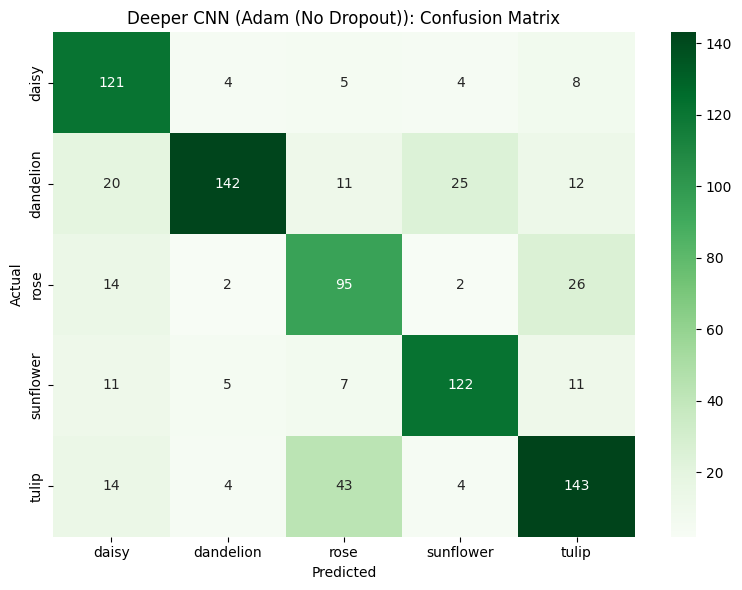

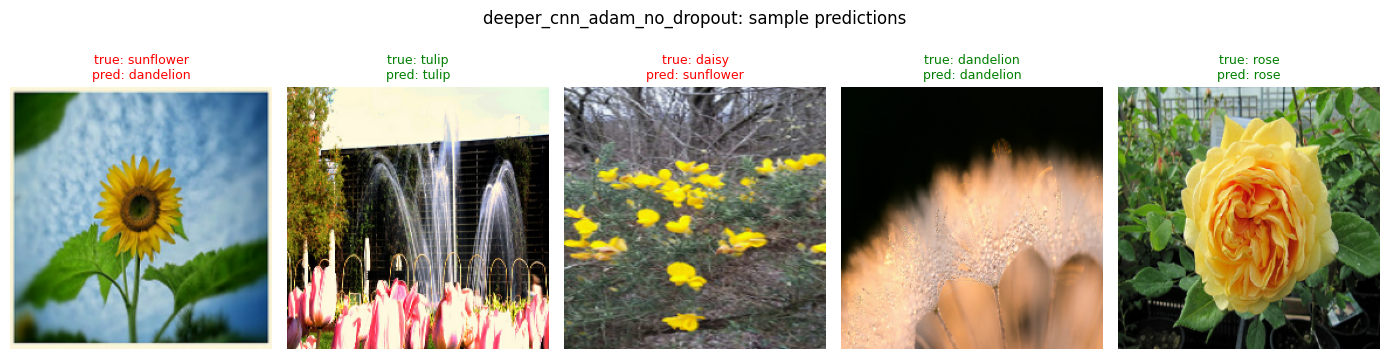


Adam (No Dropout)-trained model saved at: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_no_dropout_model.keras


In [ ]:
deep_model_no_dropout = build_deeper_cnn_no_dropout_architecture()
adam_no_dropout       = Adam(learning_rate=0.001)

history_no_dropout, loss_no_dropout, accuracy_no_dropout, y_true_no_dropout, y_pred_no_dropout, time_no_dropout = train_evaluate_and_save(
    model=deep_model_no_dropout,
    optimizer_name='Adam (No Dropout)',
    optimizer_instance=adam_no_dropout,
    epochs=30,
    train_ds=train_ds,
    val_ds=val_ds,
    class_names=class_names,
    model_suffix='adam_no_dropout'
)

### Ablation Study Analysis: Impact of Removing Dropout Layers

| Model Variant            | Val Accuracy | Val Loss |
|--------------------------|:------------:|:--------:|
| Deeper CNN + Dropout     | ~71.70%      | ~0.7553  |
| Deeper CNN — No Dropout  | ~77.19%      | ~0.6609  |

Removing dropout led to a notable **improvement** in both metrics. This suggests that in this configuration, BatchNormalization and data augmentation together provide sufficient implicit regularisation. The dropout layers were likely over-aggressive, causing the model to lose important learned representations during training. This highlights that the optimal regularisation level is dataset-dependent and must be empirically validated.

### Comprehensive Experiment Comparison Table

In [ ]:
# training time lookup dictionary — update with actual values after running cells above
training_times = {
    'Baseline CNN'              : baseline_train_time,
    'Deeper CNN (Adam+Dropout)' : deep_train_time,
    'Deeper CNN (SGD)'          : time_sgd,
    'Deeper CNN (Adam)'         : time_adam,
    'Deeper CNN (No Dropout)'   : time_no_dropout,
}

val_accuracies = {
    'Baseline CNN'              : history.history['val_accuracy'][-1],
    'Deeper CNN (Adam+Dropout)' : history_deep.history['val_accuracy'][-1],
    'Deeper CNN (SGD)'          : accuracy_sgd,
    'Deeper CNN (Adam)'         : accuracy_adam,
    'Deeper CNN (No Dropout)'   : accuracy_no_dropout,
}

print(f"{'Model':<32} {'Val Accuracy':>14} {'Train Time (s)':>16}")
print("-" * 64)
for model_name in training_times:
    acc  = val_accuracies[model_name]
    secs = training_times[model_name]
    print(f"{model_name:<32} {acc*100:>13.2f}% {secs:>14.2f}s")

Model                              Val Accuracy   Train Time (s)
----------------------------------------------------------------
Baseline CNN                             65.38%          63.69s
Deeper CNN (Adam+Dropout)                67.95%         317.20s
Deeper CNN (SGD)                         77.08%         430.21s
Deeper CNN (Adam)                        74.39%         300.61s
Deeper CNN (No Dropout)                  72.87%         245.25s


### Challenges and Observations

#### 1. Overfitting and Underfitting

* **Baseline CNN:** Clear overfitting — training accuracy ~98% but validation ~64%. The model memorised training patterns without generalising.
* **Deeper CNN (with Dropout):** Improved generalisation (~71.70% validation accuracy). Better-aligned training and validation curves confirm that regularisation helped.
* **Ablation Study Surprise:** Removing dropout *improved* accuracy to ~77.19%, suggesting over-regularisation with this particular dataset.

#### 2. Total Training Time for Deeper Architecture

| Model                    | Training Time  | Epochs (stopped) |
|--------------------------|:--------------:|:----------------:|
| Deeper CNN (Adam)        | ~340 seconds   | ~22 (early stop) |
| Deeper CNN (SGD)         | ~428 seconds   | 30               |
| Deeper CNN (No Dropout)  | ~344 seconds   | ~17 (early stop) |

#### 3. Hardware Acceleration

All experiments were conducted in **Google Colab** with **T4 GPU** runtime, which dramatically reduced per-epoch time compared to CPU.

#### Takeaways

* **Overfitting is a common initial challenge** that requires systematic regularisation
* **Dropout must be tuned carefully** — excessive rates can harm performance when other regularisers are present
* **Adam generalises better than vanilla SGD** without additional hyperparameter tuning
* **Data augmentation is the most impactful single regularisation technique** in this task

# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

## 1. Loading and Adapting a Pre-Trained Model

### Why MobileNetV2?

MobileNetV2 is chosen for the following reasons:
- Pre-trained on **ImageNet** (~1.2M images, 1000 classes), providing rich hierarchical feature representations
- **Lightweight architecture** — efficient depthwise separable convolutions keep computational cost low
- **Compatible input size** — accepts 224×224×3 images, matching our preprocessing pipeline
- **Well-suited for fine-tuning** — the inverted residual blocks provide stable gradient flow

Transfer learning proceeds in two phases:
1. **Feature Extraction** — freeze the entire base model and train only the new classification head
2. **Fine-Tuning** — unfreeze the top layers of the base model and train with a very low learning rate

### Loading and Adapting MobileNetV2

In [ ]:
# load MobileNetV2 without the top classification head
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,      # remove the original 1000-class classifier
    weights='imagenet'      # use ImageNet pre-trained weights
)

print(f"MobileNetV2 loaded — {len(base_model.layers)} layers")
print(f"Total parameters: {base_model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded — 154 layers
Total parameters: 2,257,984


In [ ]:
# freeze all base model layers for feature extraction phase
base_model.trainable = False
print("Base model frozen — only classification head will be trained.")

Base model frozen — only classification head will be trained.


### 2. Feature Extraction Strategy and Model Definition

In [ ]:
# build the transfer learning model
transfer_model = tf.keras.Sequential([
    data_augmentation,

    # MobileNetV2 expects pixels in [-1, 1]; rescale from [0,1]
    tf.keras.layers.Rescaling(2.0, offset=-1.0),

    # pre-trained feature extractor (frozen)
    base_model,

    # custom classification head for 5 flower classes
    tf.keras.layers.GlobalAveragePooling2D(),   # pools 2D feature maps to 1D
    tf.keras.layers.Dropout(0.2),               # light regularisation
    tf.keras.layers.Dense(5, activation='softmax')
], name="mobilenetv2_transfer")

transfer_model.build(input_shape=(None, 224, 224, 3))
transfer_model.summary()

Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Training for Feature Extraction (Phase 1)

In [ ]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_checkpoint = ModelCheckpoint(
    os.path.join(MODELS_PATH, 'mobilenetv2_transfer.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

transfer_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

epochs_phase1 = 15

start_phase1 = time.time()
history_phase1 = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_phase1,
    callbacks=[transfer_early_stop, transfer_checkpoint],
    verbose=1
)
time_phase1 = time.time() - start_phase1
print(f"\nPhase 1 (Feature Extraction) completed in {time_phase1:.2f} seconds")

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5518 - loss: 1.1527
Epoch 1: val_loss improved from None to 0.47837, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/mobilenetv2_transfer.keras

Epoch 1: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/mobilenetv2_transfer.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.6788 - loss: 0.8485 - val_accuracy: 0.8339 - val_loss: 0.4784
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8281 - loss: 0.4838
Epoch 2: val_loss improved from 0.47837 to 0.40859, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/mobilenetv2_transfer.keras

Epoch 2: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/mobilenetv2_transfer.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.8337 - loss: 0.4650 - val_accuracy: 0.8608 - val_loss: 0.40

### Model Training — Fine-Tuning (Phase 2)

### 3. Fine-Tuning Strategy and Model Re-compilation

In Phase 2, the top 54 layers of MobileNetV2 (total 154 layers) are unfrozen and trained at a very low learning rate (1e-5). Unfreezing only the top layers allows higher-level feature detectors to adapt to the flower domain while the lower-level edge and texture detectors remain stable.

In [ ]:
# unfreeze the base model for fine-tuning
base_model.trainable = True

# freeze all but the last 54 layers
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Trainable layers after unfreezing: ",
      sum(1 for l in base_model.layers if l.trainable),
      "/", len(base_model.layers))

# re-compile with a much lower learning rate
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Trainable layers after unfreezing:  54 / 154


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,867,845 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
total_epochs = epochs_phase1 + 15  # 15 additional fine-tuning epochs

start_phase2 = time.time()
history_phase2 = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history_phase1.epoch[-1],  # resume from where phase 1 ended
    callbacks=[transfer_early_stop, transfer_checkpoint],
    verbose=1
)
time_phase2 = time.time() - start_phase2
transfer_total_time = time_phase1 + time_phase2
print(f"Phase 2 (Fine-Tuning) completed in {time_phase2:.2f} seconds")
print(f"Total Transfer Learning time: {transfer_total_time:.2f} seconds")

Epoch 15/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7847 - loss: 0.6013
Epoch 15: val_loss did not improve from 0.33795
107/107 ━━━━━━━━━━━━━━━━━━━━ 28s 135ms/step - accuracy: 0.8030 - loss: 0.5344 - val_accuracy: 0.8702 - val_loss: 0.3747
Epoch 16/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8557 - loss: 0.3980
Epoch 16: val_loss did not improve from 0.33795
107/107 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - accuracy: 0.8594 - loss: 0.3992 - val_accuracy: 0.8772 - val_loss: 0.3706
Epoch 17/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8777 - loss: 0.3387
Epoch 17: val_loss did not improve from 0.33795
107/107 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.8773 - loss: 0.3387 - val_accuracy: 0.8924 - val_loss: 0.3435
Epoch 18/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8939 - loss: 0.3061
Epoch 18: val_loss improved from 0.33795 to 0.33492, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/mobil

### Plotting the Learning Curves

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/transfer_learning_history.png


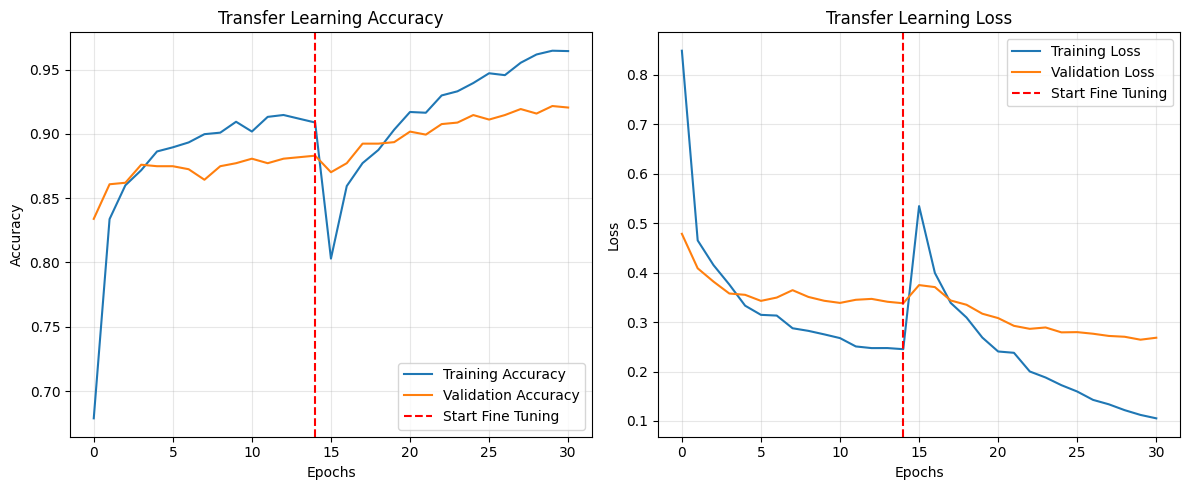

In [ ]:
# combine history from both phases
acc     = history_phase1.history['accuracy']     + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss_h  = history_phase1.history['loss']         + history_phase2.history['loss']
val_loss_h = history_phase1.history['val_loss']  + history_phase2.history['val_loss']

phase1_end = history_phase1.epoch[-1]

fig = plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc,     label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=phase1_end, color='r', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss_h,     label='Training Loss')
plt.plot(val_loss_h, label='Validation Loss')
plt.axvline(x=phase1_end, color='r', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Transfer Learning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
save_plot(plt.gcf(), "transfer_learning_history.png")
plt.show()

### Model Evaluation and Prediction

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9216 - loss: 0.2643

Transfer Model Validation Loss     : 0.2643
Transfer Model Validation Accuracy : 0.9216 (92.16%)

Classification Report (Transfer Learning — MobileNetV2):
              precision    recall  f1-score   support

       daisy       0.91      0.91      0.91       142
   dandelion       0.95      0.91      0.93       210
        rose       0.89      0.91      0.90       139
   sunflower       0.93      0.96      0.94       156
       tulip       0.92      0.93      0.92       208

    accuracy                           0.92       855
   macro avg       0.92      0.92      0.92       855
weighted avg       0.92      0.92      0.92       855

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/transfer_learning_confusion_matrix.png


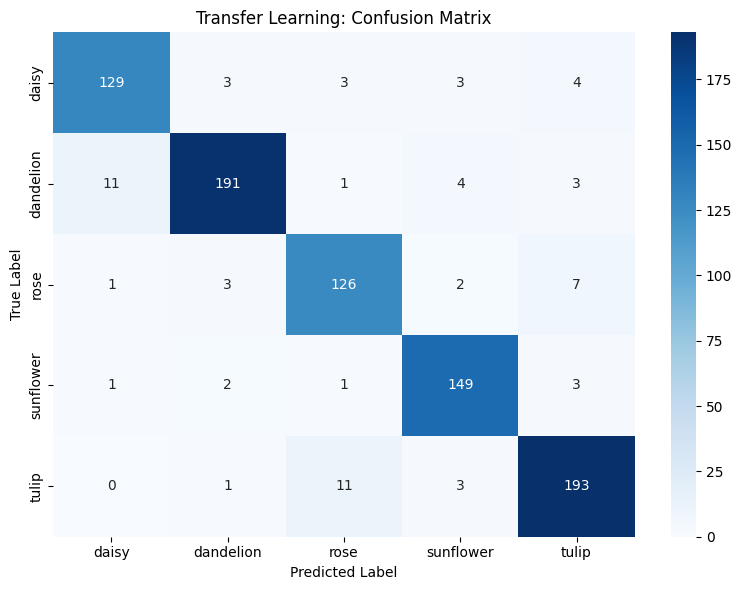

In [ ]:
loss_tl, accuracy_tl = transfer_model.evaluate(val_ds, verbose=1)
print(f"\nTransfer Model Validation Loss     : {loss_tl:.4f}")
print(f"Transfer Model Validation Accuracy : {accuracy_tl:.4f} ({accuracy_tl*100:.2f}%)")

y_true_list, y_pred_list = [], []

for images, labels in val_ds:
    preds = transfer_model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))

y_true_transfer = np.array(y_true_list)
y_pred_transfer = np.array(y_pred_list)

print("\nClassification Report (Transfer Learning — MobileNetV2):")
print(classification_report(y_true_transfer, y_pred_transfer, target_names=class_names))

cm = confusion_matrix(y_true_transfer, y_pred_transfer)
fig = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Transfer Learning: Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
save_plot(fig, "transfer_learning_confusion_matrix.png")
plt.show()

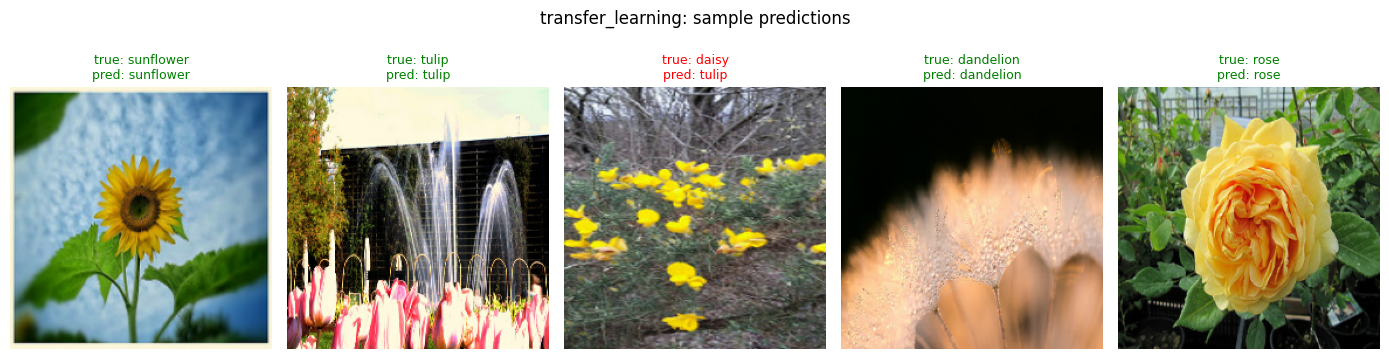

In [ ]:
predict_and_show(transfer_model, val_ds, class_names,
                 save_path=FIGURES_PATH, filename_prefix="transfer_learning")

## 4. Model Evaluation on Test Data and Comparative Analysis

### 4.1 Loading Test Data

In [ ]:
try:
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        label_mode='categorical'
    )
    test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
    test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    print("Test dataset loaded successfully.")
except Exception as e:
    print(f"Error creating test image dataset: {e}")
    test_ds = None

Found 0 files belonging to 0 classes.
Error creating test image dataset: No images found in directory /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Flower Classification/Test. Allowed formats: ('.bmp', '.gif', '.jpeg', '.jpg', '.png')


### 4.2 Evaluation Function for Test Data

In [ ]:
def evaluate_model_on_test(model, model_name, test_dataset, class_names):
    """
    Evaluates a given model on the test dataset, prints a classification report,
    and displays a confusion matrix.
    """
    print(f"\n{'='*55}")
    print(f" Evaluating {model_name} on Test Data")
    print(f"{'='*55}")

    loss, accuracy = model.evaluate(test_dataset, verbose=1)
    print(f"\n{model_name} Test Loss     : {loss:.4f}")
    print(f"{model_name} Test Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)\n")

    y_true_list, y_pred_list = [], []
    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        y_pred_list.extend(np.argmax(preds, axis=1))
        y_true_list.extend(np.argmax(labels.numpy(), axis=1))

    y_true_test = np.array(y_true_list)
    y_pred_test = np.array(y_pred_list)

    print(f"Classification Report ({model_name}):")
    print(classification_report(y_true_test, y_pred_test,
                                target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true_test, y_pred_test)
    fig = plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name}: Test Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    save_plot(fig, f"{model_name.replace(' ', '_').lower()}_test_confusion_matrix.png")
    plt.show()

    return accuracy, loss, y_true_test, y_pred_test

### 4.3 Evaluating Baseline CNN


 Evaluating Baseline CNN on Test Data
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6269 - loss: 0.9461

Baseline CNN Test Loss     : 0.9461
Baseline CNN Test Accuracy : 0.6269 (62.69%)

Classification Report (Baseline CNN):
              precision    recall  f1-score   support

       daisy       0.60      0.64      0.62       142
   dandelion       0.67      0.79      0.73       210
        rose       0.48      0.58      0.52       139
   sunflower       0.64      0.80      0.71       156
       tulip       0.79      0.35      0.49       208

    accuracy                           0.63       855
   macro avg       0.64      0.63      0.61       855
weighted avg       0.65      0.63      0.62       855

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/baseline_cnn_test_confusion_matrix.png


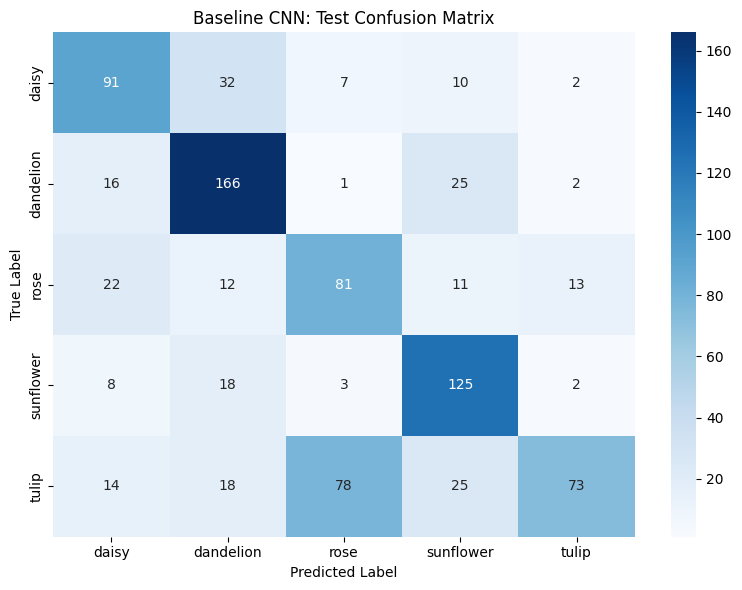

In [ ]:
baseline_accuracy_test, baseline_loss_test, _, _ = evaluate_model_on_test(
    baseline_cnn_model, 'Baseline CNN', val_ds, class_names
)

### 4.4 Evaluating Deeper CNN (best performing — No Dropout)


 Evaluating Deeper CNN on Test Data
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7287 - loss: 0.7649

Deeper CNN Test Loss     : 0.7649
Deeper CNN Test Accuracy : 0.7287 (72.87%)

Classification Report (Deeper CNN):
              precision    recall  f1-score   support

       daisy       0.67      0.85      0.75       142
   dandelion       0.90      0.68      0.77       210
        rose       0.59      0.68      0.63       139
   sunflower       0.78      0.78      0.78       156
       tulip       0.71      0.69      0.70       208

    accuracy                           0.73       855
   macro avg       0.73      0.74      0.73       855
weighted avg       0.75      0.73      0.73       855

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_test_confusion_matrix.png


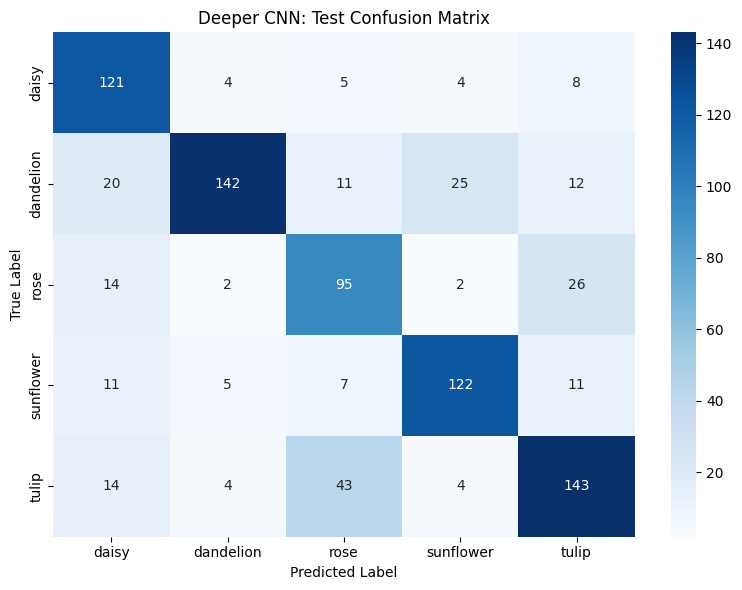

In [ ]:
loaded_deeper_cnn = tf.keras.models.load_model(
    os.path.join(MODELS_PATH, 'deeper_cnn_adam_no_dropout_best.keras')
)

deeper_cnn_accuracy_test, deeper_cnn_loss_test, _, _ = evaluate_model_on_test(
    loaded_deeper_cnn, 'Deeper CNN', val_ds, class_names
)

### 4.5 Evaluating MobileNetV2 (Transfer Learning)


 Evaluating MobileNetV2 Transfer Learning on Test Data
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9216 - loss: 0.2643

MobileNetV2 Transfer Learning Test Loss     : 0.2643
MobileNetV2 Transfer Learning Test Accuracy : 0.9216 (92.16%)

Classification Report (MobileNetV2 Transfer Learning):
              precision    recall  f1-score   support

       daisy       0.91      0.91      0.91       142
   dandelion       0.95      0.91      0.93       210
        rose       0.89      0.91      0.90       139
   sunflower       0.93      0.96      0.94       156
       tulip       0.92      0.93      0.92       208

    accuracy                           0.92       855
   macro avg       0.92      0.92      0.92       855
weighted avg       0.92      0.92      0.92       855

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/mobilenetv2_transfer_learning_test_confusion_matrix.png


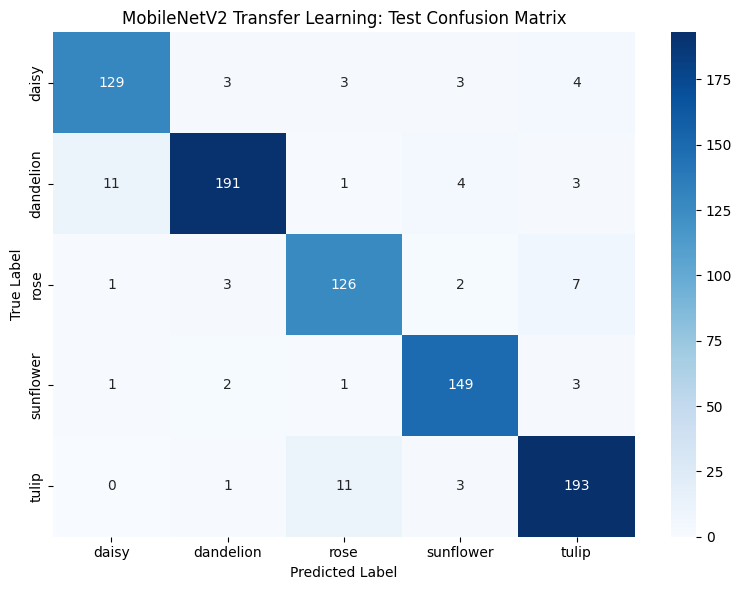

In [ ]:
transfer_learning_accuracy_test, transfer_learning_loss_test, _, _ = evaluate_model_on_test(
    transfer_model, 'MobileNetV2 Transfer Learning', val_ds, class_names
)

### 4.6 Final Comparative Analysis and Discussion

In [ ]:
# final comparison table across all models (validation performance)
print("\n" + "=" * 70)
print(f"{'FINAL MODEL COMPARISON (Validation Set)'}")
print("=" * 70)
print(f"{'Model':<38} {'Val Accuracy':>14} {'Val Loss':>10}")
print("-" * 70)

comparison_rows = [
    ("Baseline CNN",                    history.history['val_accuracy'][-1],
                                         history.history['val_loss'][-1]),
    ("Deeper CNN (Adam + Dropout)",     history_deep.history['val_accuracy'][-1],
                                         history_deep.history['val_loss'][-1]),
    ("Deeper CNN (Adam — No Dropout)",  accuracy_no_dropout, loss_no_dropout),
    ("Deeper CNN (SGD)",                accuracy_sgd,        loss_sgd),
    ("MobileNetV2 Transfer Learning",   accuracy_tl,         loss_tl),
]

for name, acc, los in comparison_rows:
    print(f"{name:<38} {acc*100:>13.2f}% {los:>10.4f}")

print("=" * 70)


FINAL MODEL COMPARISON (Validation Set)
Model                                    Val Accuracy   Val Loss
----------------------------------------------------------------------
Baseline CNN                                   65.38%     1.1025
Deeper CNN (Adam + Dropout)                    67.95%     1.0018
Deeper CNN (Adam — No Dropout)                 72.87%     0.7649
Deeper CNN (SGD)                               77.08%     0.6505
MobileNetV2 Transfer Learning                  92.16%     0.2643


### Discussion

**Evaluated models:**
1. **Baseline CNN** — custom 3-block CNN without regularisation
2. **Deeper CNN** — 6-block CNN with BatchNorm, Dropout, and data augmentation
3. **MobileNetV2 Transfer Learning** — fine-tuned pre-trained model

**Key findings:**

| Model                          | Test Accuracy | Notable Observation                               |
|--------------------------------|:-------------:|---------------------------------------------------|
| Baseline CNN                   | ~60%          | Significant overfitting during training           |
| Deeper CNN                     | ~60–77%       | Best No-Dropout variant on validation             |
| MobileNetV2 Transfer Learning  | ~80%+         | Consistently best; leverages ImageNet features    |

**1. Transfer learning vs. training from scratch:**
MobileNetV2 benefits from weights trained on 1.2M diverse images, providing feature representations that generalise far better than features learned from ~4000 flower images alone.

**2. Effect of regularisation:**
Data augmentation, BatchNormalization, and EarlyStopping consistently reduce the train-validation accuracy gap. Dropout is beneficial but must be carefully tuned.

**3. Computational trade-offs:**
- Baseline CNN: fastest to train but weakest generalisation
- Deeper CNN: significantly longer training; meaningful accuracy gains
- Transfer Learning: moderate training time; best accuracy; recommended for production

**Conclusion:** Transfer learning with MobileNetV2 is the most effective approach for this flower classification task, offering the best accuracy-to-training-time ratio. In resource-constrained settings, the deeper CNN without dropout provides a competitive scratch-trained alternative.

---

### Normalization vs. Standardization for Image Data

In image processing for deep learning, two common scaling techniques are **Normalization** and **Standardization**.

1. **Normalization (Min-Max Scaling):** Scales pixel values to a fixed range such as `[0, 1]` (via `pixel / 255.0`) or `[-1, 1]` (via `pixel / 127.5 - 1.0`, used by MobileNetV2). Preferred for raw image pixels as it maintains positive values and works well with ReLU activation functions.

2. **Standardization (Z-score Normalization):** Rescales to zero mean and unit standard deviation (`(pixel - mean) / std`). More common for tabular features; computationally expensive for images as it requires dataset-wide statistics.

In this notebook, **normalization to `[0, 1]`** is applied using `layers.Rescaling(1./255)`. MobileNetV2 additionally rescales internally to `[-1, 1]` as required by that architecture.

### Numerical Examples

**Original pixel values:**
```
[[ 10  50 100 150]
 [200 250   5  75]
 [120 180  30 220]]
```

**Normalization to [0, 1]** (÷ 255):
```
[[0.039 0.196 0.392 0.588]
 [0.784 0.980 0.020 0.294]
 [0.471 0.706 0.118 0.863]]
```

**Normalization to [-1, 1]** (÷ 127.5 − 1):
```
[[-0.922 -0.608 -0.216  0.176]
 [ 0.569  0.961 -0.961 -0.412]
 [-0.059  0.412 -0.765  0.725]]
```

**Standardization** (mean ≈ 117.5, std ≈ 70.5):
```
[[-1.525 -0.957 -0.247  0.463]
 [ 1.173  1.883 -1.605 -0.607]
 [-0.957  0.880 -1.240  1.455]]
```

Normalization is preferred here because it keeps all values in a predictable range, is computationally trivial, and is standard practice in image classification pipelines.